In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3588, 19)

In [5]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,maa bhagwati residency,sector 7,0.45,5000.0,2.0,2.0,1,4.0,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
1,1,flat,apna enclave,sector 3,0.50,7692.0,2.0,2.0,1,1.0,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2,3,flat,smart world orchard,sector 61,1.47,12250.0,2.0,2.0,2,2.0,New Property,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
3,4,flat,parkwood westend,sector 92,0.70,5204.0,2.0,2.0,3,5.0,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,flat,signature global infinity mall,sector 36,0.41,6269.0,2.0,2.0,3,3.0,New Property,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [7]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,sector 7,0.45,2.0,2.0,1,4.0,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
1,1,flat,sector 3,0.50,2.0,2.0,1,1.0,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2,3,flat,sector 61,1.47,2.0,2.0,2,2.0,New Property,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
3,4,flat,sector 92,0.70,2.0,2.0,3,5.0,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,flat,sector 36,0.41,2.0,2.0,3,3.0,New Property,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### luxury score

<Axes: ylabel='luxury_score'>

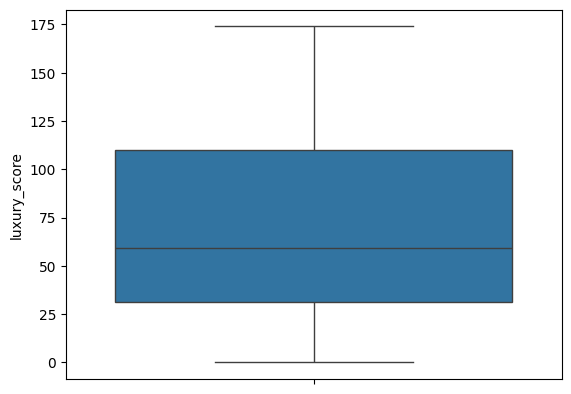

In [8]:
sns.boxplot(df['luxury_score'])

In [9]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [10]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [11]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,0,flat,sector 7,0.45,2.0,2.0,1,4.0,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0,Low
1,1,flat,sector 3,0.50,2.0,2.0,1,1.0,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,Low
2,3,flat,sector 61,1.47,2.0,2.0,2,2.0,New Property,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0,Medium
3,4,flat,sector 92,0.70,2.0,2.0,3,5.0,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,Low
4,5,flat,sector 36,0.41,2.0,2.0,3,3.0,New Property,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low


### floorNum

<Axes: ylabel='floorNum'>

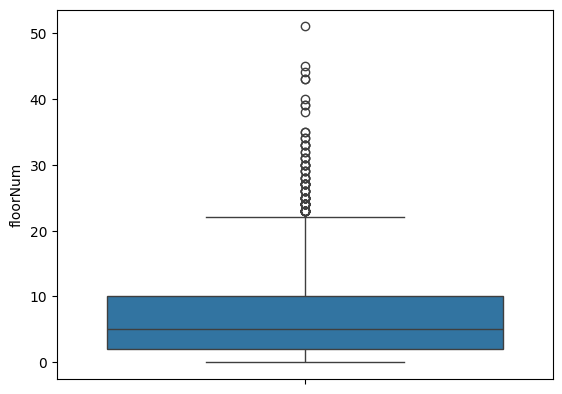

In [12]:
sns.boxplot(df['floorNum'])

In [13]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [14]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [15]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,0,flat,sector 7,0.45,2.0,2.0,1,4.0,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0,Low,Mid Floor
1,1,flat,sector 3,0.50,2.0,2.0,1,1.0,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0,Low,Low Floor
2,3,flat,sector 61,1.47,2.0,2.0,2,2.0,New Property,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0,Medium,Low Floor
3,4,flat,sector 92,0.70,2.0,2.0,3,5.0,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,Low,Mid Floor
4,5,flat,sector 36,0.41,2.0,2.0,3,3.0,New Property,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low,Mid Floor


In [16]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [17]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0,flat,sector 7,0.45,2.0,2.0,1,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,Mid Floor
1,1,flat,sector 3,0.50,2.0,2.0,1,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,Low Floor
2,3,flat,sector 61,1.47,2.0,2.0,2,New Property,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,Medium,Low Floor
3,4,flat,sector 92,0.70,2.0,2.0,3,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,Low,Mid Floor
4,5,flat,sector 36,0.41,2.0,2.0,3,New Property,654.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,Mid Floor


In [18]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 's

In [19]:
X_label

,Unnamed: 0,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0,0.0,80.0,2.0,2.0,1.0,3.0,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,1,0.0,35.0,2.0,2.0,1.0,2.0,722.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,3,0.0,70.0,2.0,2.0,2.0,1.0,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
3,4,0.0,106.0,2.0,2.0,3.0,4.0,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
4,5,0.0,41.0,2.0,2.0,3.0,1.0,654.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3583,3798,1.0,65.0,3.0,3.0,3.0,0.0,1650.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0
3584,3799,1.0,32.0,4.0,4.0,3.0,0.0,1800.0,1.0,1.0,0.0,1.0,0.0,1.0,2.0,1.0
3585,3800,1.0,31.0,3.0,2.0,3.0,2.0,1350.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3586,3801,1.0,32.0,3.0,3.0,2.0,0.0,1350.0,1.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0


In [20]:
y_label

0       0.45
1       0.50
2       1.47
3       0.70
4       0.41
        ... 
3583    4.75
3584    5.50
3585    4.25
3586    4.50
3587    3.25
Name: price, Length: 3588, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

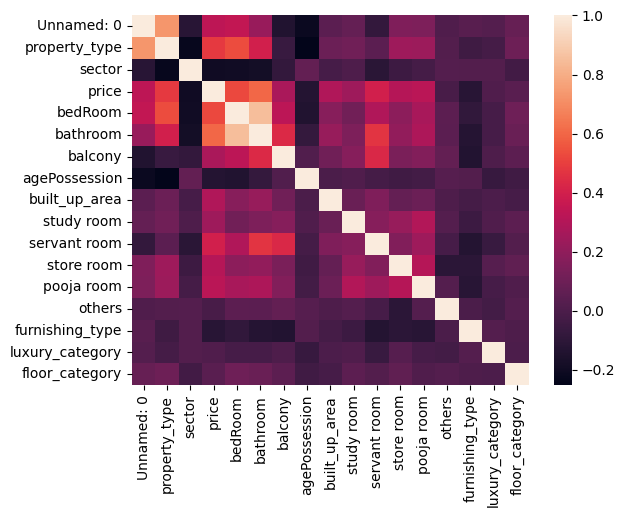

In [21]:
 sns.heatmap(data_label_encoded.corr())

In [22]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,property_type,0.484595
1,sector,-0.199085
2,price,1.000000
3,bedRoom,0.524919
4,bathroom,0.603091
5,balcony,0.272499
6,agePossession,-0.130735
7,built_up_area,0.292238
8,study room,0.240559
9,servant room,0.394664


### Technique 2 - Random Forest Feature Importance

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
7,built_up_area,0.621887
0,Unnamed: 0,0.155215
2,sector,0.091084
4,bathroom,0.026917
3,bedRoom,0.017433
1,property_type,0.017317
9,servant room,0.011274
6,agePossession,0.011200
5,balcony,0.010451
13,furnishing_type,0.007343


### Technique 3 - Gradient Boosting Feature importances

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
7,built_up_area,0.674334
0,Unnamed: 0,0.147668
2,sector,0.090308
4,bathroom,0.037969
3,bedRoom,0.019943
9,servant room,0.015639
6,agePossession,0.004835
10,store room,0.002592
13,furnishing_type,0.001490
5,balcony,0.001424


### Technique 4 - Permutation Importance

In [25]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
7,built_up_area,0.756408
0,Unnamed: 0,0.161868
2,sector,0.150176
4,bathroom,0.017834
3,bedRoom,0.014281
9,servant room,0.008907
1,property_type,0.008514
6,agePossession,0.005792
8,study room,0.003706
5,balcony,0.002531


### Technique 5 - LASSO

In [26]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5


,feature,lasso_coeff
4,bathroom,1.118423
1,property_type,0.715301
7,built_up_area,0.404874
9,servant room,0.392263
10,store room,0.255254
8,study room,0.216218
0,Unnamed: 0,0.171027
11,pooja room,0.153223
5,balcony,0.106188
14,luxury_category,0.069560


### Technique 6 - RFE

In [27]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
7,built_up_area,0.619092
0,Unnamed: 0,0.157655
2,sector,0.091931
4,bathroom,0.027286
3,bedRoom,0.017436
1,property_type,0.015206
9,servant room,0.013349
6,agePossession,0.011355
5,balcony,0.010568
13,furnishing_type,0.007615


### Technique 7 - Linear Regression Weights

In [28]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
4,bathroom,1.186678
1,property_type,0.734393
7,built_up_area,0.411585
9,servant room,0.386669
10,store room,0.256304
8,study room,0.220760
0,Unnamed: 0,0.179997
11,pooja room,0.158408
5,balcony,0.117631
14,luxury_category,0.078574


### Technique 8 - SHAP

In [29]:
!pip install shap

In [30]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values


array([[-1.51724076e-01, -2.54393575e-02, -5.20999526e-03, ...,
        -7.86297406e-03, -8.08278607e-03, -9.61777699e-03],
       [-1.62072006e-01, -2.87035691e-02,  1.40522269e-01, ...,
         1.91437337e-02, -9.25815941e-03, -7.76395164e-03],
       [-1.35935963e-01, -4.01009322e-02,  5.23894024e-01, ...,
        -5.40620371e-03, -5.58895509e-04, -1.65768455e-02],
       ...,
       [ 1.17377249e+00,  6.33684777e-01,  5.07657132e-01, ...,
        -1.76958573e-02, -1.42015140e-02,  2.43893471e-03],
       [ 1.26052544e+00,  5.76156047e-01,  5.02618160e-01, ...,
        -1.07116463e-02,  1.92454737e-02,  1.24889332e-02],
       [ 1.71166224e+00,  1.91657108e-01,  2.51747622e-01, ...,
        -7.33667110e-02,  8.52739945e-02,  1.81436532e-02]],
      shape=(3588, 16))

In [31]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
7,built_up_area,1.259370
0,Unnamed: 0,0.408728
2,sector,0.366898
4,bathroom,0.104247
1,property_type,0.098957
9,servant room,0.066560
3,bedRoom,0.039042
5,balcony,0.036170
13,furnishing_type,0.022315
15,floor_category,0.021121


In [32]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [33]:
final_fi_df


,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.484595,0.017317,0.000836,0.008514,0.715301,0.015206,0.734393,0.098957
sector,-0.199085,0.091084,0.090308,0.150176,-0.129885,0.091931,-0.137940,0.366898
bedRoom,0.524919,0.017433,0.019943,0.014281,-0.289674,0.017436,-0.378405,0.039042
bathroom,0.603091,0.026917,0.037969,0.017834,1.118423,0.027286,1.186678,0.104247
balcony,0.272499,0.010451,0.001424,0.002531,0.106188,0.010568,0.117631,0.036170
agePossession,-0.130735,0.011200,0.004835,0.005792,-0.055697,0.011355,-0.065294,0.020896
built_up_area,0.292238,0.621887,0.674334,0.756408,0.404874,0.619092,0.411585,1.259370
study room,0.240559,0.006660,0.000621,0.003706,0.216218,0.005465,0.220760,0.016745
servant room,0.394664,0.011274,0.015639,0.008907,0.392263,0.013349,0.386669,0.066560


In [34]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [35]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.728951
sector             0.130648
bathroom           0.035406
bedRoom            0.019626
property_type      0.019122
servant room       0.017709
agePossession      0.009675
balcony            0.009297
furnishing_type    0.005838
study room         0.005385
floor_category     0.004837
luxury_category    0.004333
store room         0.003969
pooja room         0.003227
others             0.001977
dtype: float64

In [36]:
# to drop pooja room, study room, others
X_label

,Unnamed: 0,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0,0.0,80.0,2.0,2.0,1.0,3.0,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,1,0.0,35.0,2.0,2.0,1.0,2.0,722.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,3,0.0,70.0,2.0,2.0,2.0,1.0,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
3,4,0.0,106.0,2.0,2.0,3.0,4.0,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
4,5,0.0,41.0,2.0,2.0,3.0,1.0,654.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3583,3798,1.0,65.0,3.0,3.0,3.0,0.0,1650.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0
3584,3799,1.0,32.0,4.0,4.0,3.0,0.0,1800.0,1.0,1.0,0.0,1.0,0.0,1.0,2.0,1.0
3585,3800,1.0,31.0,3.0,2.0,3.0,2.0,1350.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3586,3801,1.0,32.0,3.0,3.0,2.0,0.0,1350.0,1.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0


In [37]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [38]:
scores.mean()

np.float64(0.735122626701328)

In [39]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [40]:
scores.mean()

np.float64(0.7359942516689613)

In [41]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [42]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [43]:
export_df

,Unnamed: 0,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0,0.0,80.0,2.0,2.0,1.0,3.0,1000.0,0.0,0.0,1.0,1.0,2.0,0.45
1,1,0.0,35.0,2.0,2.0,1.0,2.0,722.0,0.0,0.0,0.0,1.0,1.0,0.50
2,3,0.0,70.0,2.0,2.0,2.0,1.0,1333.0,0.0,0.0,1.0,2.0,1.0,1.47
3,4,0.0,106.0,2.0,2.0,3.0,4.0,1217.0,0.0,0.0,1.0,1.0,2.0,0.70
4,5,0.0,41.0,2.0,2.0,3.0,1.0,654.0,0.0,0.0,1.0,1.0,2.0,0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3583,3798,1.0,65.0,3.0,3.0,3.0,0.0,1650.0,0.0,1.0,0.0,2.0,1.0,4.75
3584,3799,1.0,32.0,4.0,4.0,3.0,0.0,1800.0,1.0,0.0,1.0,2.0,1.0,5.50
3585,3800,1.0,31.0,3.0,2.0,3.0,2.0,1350.0,0.0,0.0,1.0,1.0,1.0,4.25
3586,3801,1.0,32.0,3.0,3.0,2.0,0.0,1350.0,1.0,0.0,1.0,2.0,1.0,4.50
